In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("ecommerce_customer_data_large.csv")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177.0,1.0,2427.0,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0
1,44605,2021-05-16 13:57:44,Electronics,174.0,3.0,2448.0,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0
2,44605,2020-07-13 06:16:57,Books,413.0,1.0,2345.0,Credit Card,31.0,1.0,John Rivera,31.0,Female,0.0
3,44605,2023-01-17 13:14:36,Electronics,396.0,3.0,937.0,Cash,31.0,0.0,John Rivera,31.0,Female,0.0
4,44605,2021-05-01 11:29:27,Books,259.0,4.0,2598.0,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0


In [3]:
print("Shape of Dataset:", df.shape)
print("\nColumns:")
print(df.columns)

Shape of Dataset: (98485, 13)

Columns:
Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98485 entries, 0 to 98484
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer ID            98485 non-null  int64  
 1   Purchase Date          98485 non-null  object 
 2   Product Category       98484 non-null  object 
 3   Product Price          98484 non-null  float64
 4   Quantity               98484 non-null  float64
 5   Total Purchase Amount  98484 non-null  float64
 6   Payment Method         98484 non-null  object 
 7   Customer Age           98484 non-null  float64
 8   Returns                79873 non-null  float64
 9   Customer Name          98484 non-null  object 
 10  Age                    98484 non-null  float64
 11  Gender                 98484 non-null  object 
 12  Churn                  98484 non-null  float64
dtypes: float64(7), int64(1), object(5)
memory usage: 9.8+ MB


In [5]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,98485.000000,98484.000000,98484.000000,98484.000000,98484.000000,79873.000000,98484.000000,98484.000000
mean,24974.076052,254.610363,3.006499,2721.682639,43.724331,0.502648,43.724331,0.197738
std,14397.843062,141.648120,1.414299,1441.656218,15.330789,0.499996,15.330789,0.398295
min,6.000000,10.000000,1.000000,101.000000,18.000000,0.000000,18.000000,0.000000
25%,12556.000000,132.000000,2.000000,1475.000000,30.000000,0.000000,30.000000,0.000000
50%,24964.000000,254.000000,3.000000,2722.000000,44.000000,1.000000,44.000000,0.000000
75%,37298.000000,377.000000,4.000000,3971.000000,57.000000,1.000000,57.000000,0.000000
max,50000.000000,500.000000,5.000000,5349.000000,70.000000,1.000000,70.000000,1.000000


In [6]:
df.dtypes

,0
Customer ID,int64
Purchase Date,object
Product Category,object
Product Price,float64
Quantity,float64
Total Purchase Amount,float64
Payment Method,object
Customer Age,float64
Returns,float64
Customer Name,object


In [7]:
print(df.isnull().sum())

Customer ID                  0
Purchase Date                0
Product Category             1
Product Price                1
Quantity                     1
Total Purchase Amount        1
Payment Method               1
Customer Age                 1
Returns                  18612
Customer Name                1
Age                          1
Gender                       1
Churn                        1
dtype: int64


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df.rename(columns={"Genre":"Gender"}, inplace=True)

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177.0,1.0,2427.0,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0
1,44605,2021-05-16 13:57:44,Electronics,174.0,3.0,2448.0,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0
2,44605,2020-07-13 06:16:57,Books,413.0,1.0,2345.0,Credit Card,31.0,1.0,John Rivera,31.0,Female,0.0
3,44605,2023-01-17 13:14:36,Electronics,396.0,3.0,937.0,Cash,31.0,0.0,John Rivera,31.0,Female,0.0
4,44605,2021-05-01 11:29:27,Books,259.0,4.0,2598.0,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0


In [10]:
print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nMode")
print(df.mode().iloc[0])

Mean
Customer ID              24974.076052
Product Price              254.610363
Quantity                     3.006499
Total Purchase Amount     2721.682639
Customer Age                43.724331
Returns                      0.502648
Age                         43.724331
Churn                        0.197738
dtype: float64

Median
Customer ID              24964.0
Product Price              254.0
Quantity                     3.0
Total Purchase Amount     2722.0
Customer Age                44.0
Returns                      1.0
Age                         44.0
Churn                        0.0
dtype: float64

Mode
Customer ID                          48382.0
Purchase Date            2020-01-01 15:49:02
Product Category                 Electronics
Product Price                          207.0
Quantity                                 4.0
Total Purchase Amount                 1768.0
Payment Method                   Credit Card
Customer Age                            23.0
Returns                

In [11]:
print(df["Purchase Date"].dtype)

object


In [12]:
df["Purchase Date"] = pd.to_datetime(
    df["Purchase Date"],
    errors="coerce"
)

print(df["Purchase Date"].dtype)

datetime64[ns]


In [13]:
df["Year"] = df["Purchase Date"].dt.year
df["Month"] = df["Purchase Date"].dt.month_name()

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn,Year,Month
0,44605,2023-05-03 21:30:02,Home,177.0,1.0,2427.0,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0,2023.0,May
1,44605,2021-05-16 13:57:44,Electronics,174.0,3.0,2448.0,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0,2021.0,May
2,44605,2020-07-13 06:16:57,Books,413.0,1.0,2345.0,Credit Card,31.0,1.0,John Rivera,31.0,Female,0.0,2020.0,July
3,44605,2023-01-17 13:14:36,Electronics,396.0,3.0,937.0,Cash,31.0,0.0,John Rivera,31.0,Female,0.0,2023.0,January
4,44605,2021-05-01 11:29:27,Books,259.0,4.0,2598.0,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0,2021.0,May


In [14]:
def age_group(age):
    if age < 25:
        return "Young"
    elif age < 45:
        return "Adult"
    else:
        return "Senior"

df["Age Group"] = df["Age"].apply(age_group)

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn,Year,Month,Age Group
0,44605,2023-05-03 21:30:02,Home,177.0,1.0,2427.0,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0,2023.0,May,Adult
1,44605,2021-05-16 13:57:44,Electronics,174.0,3.0,2448.0,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0,2021.0,May,Adult
2,44605,2020-07-13 06:16:57,Books,413.0,1.0,2345.0,Credit Card,31.0,1.0,John Rivera,31.0,Female,0.0,2020.0,July,Adult
3,44605,2023-01-17 13:14:36,Electronics,396.0,3.0,937.0,Cash,31.0,0.0,John Rivera,31.0,Female,0.0,2023.0,January,Adult
4,44605,2021-05-01 11:29:27,Books,259.0,4.0,2598.0,PayPal,31.0,1.0,John Rivera,31.0,Female,0.0,2021.0,May,Adult


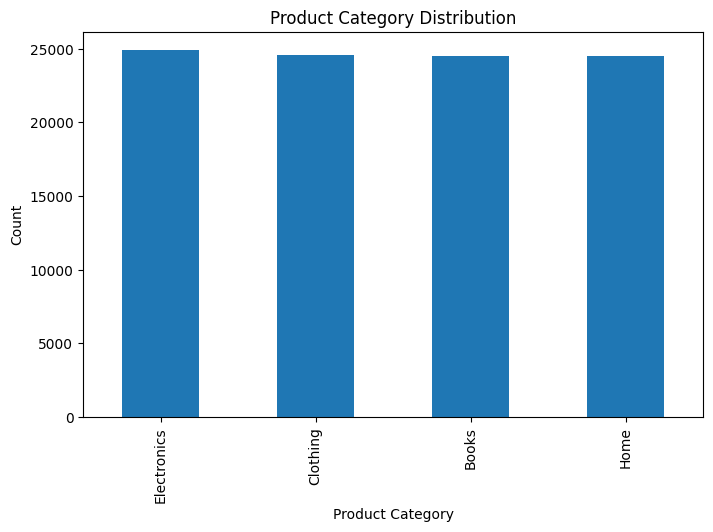

In [15]:
#Product Category Distribution
plt.figure(figsize=(8,5))

df["Product Category"].value_counts().plot(kind="bar")

plt.title("Product Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Count")

plt.show()

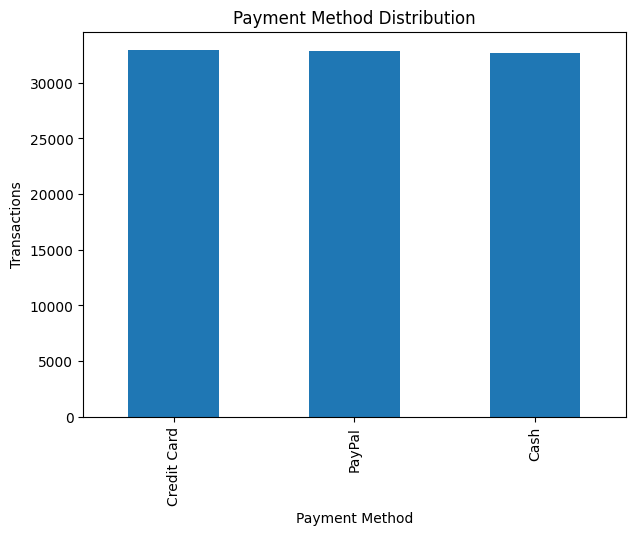

In [16]:
#Payment Method Distribution
plt.figure(figsize=(7,5))

df["Payment Method"].value_counts().plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Transactions")

plt.show()

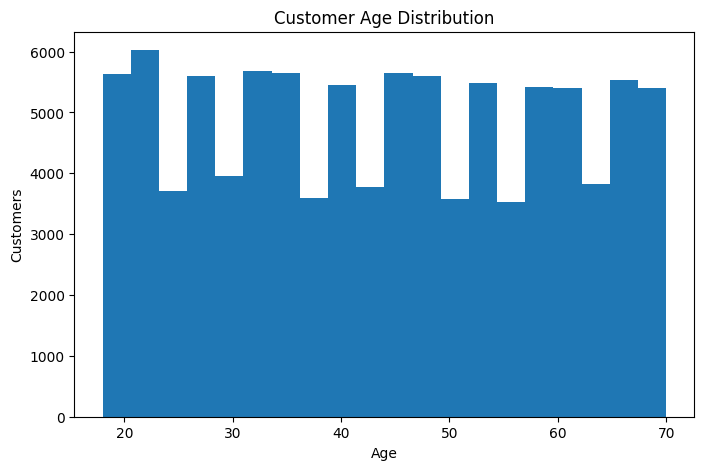

In [17]:
#Customer Age Distribution
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")

plt.show()

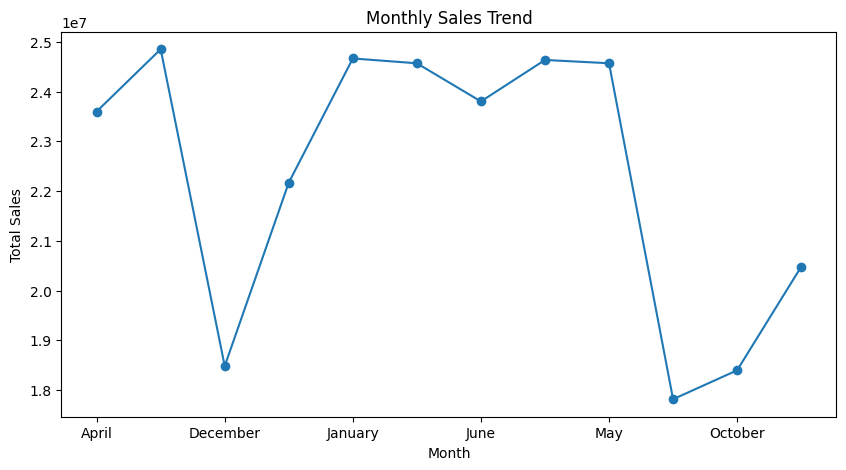

In [18]:
#Monthly Sales Trend
monthly_sales = df.groupby("Month")["Total Purchase Amount"].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

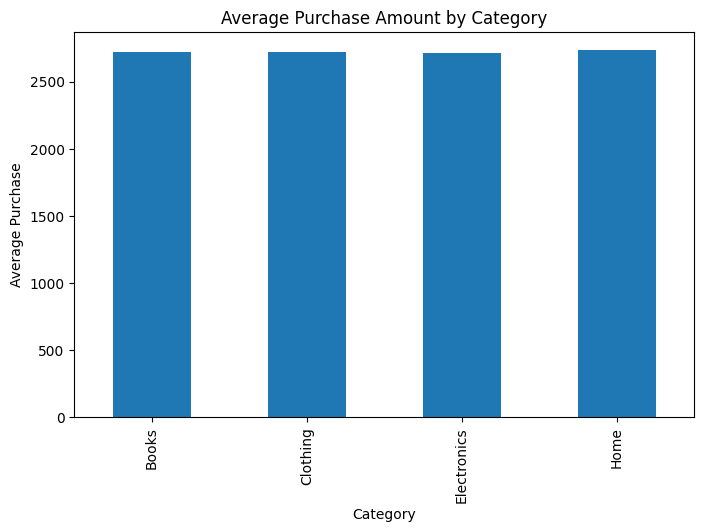

In [19]:
#Average Purchase Amount by Product Category
category_sales = df.groupby("Product Category")["Total Purchase Amount"].mean()

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Average Purchase Amount by Category")
plt.xlabel("Category")
plt.ylabel("Average Purchase")

plt.show()

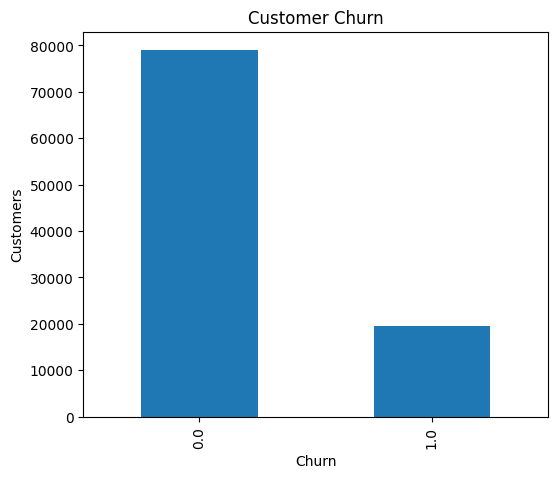

In [20]:
#Customer Churn
plt.figure(figsize=(6,5))

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Customers")

plt.show()

In [21]:
print(df.columns.tolist())

['Customer ID', 'Purchase Date', 'Product Category', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age', 'Returns', 'Customer Name', 'Age', 'Gender', 'Churn', 'Year', 'Month', 'Age Group']


In [22]:
from sklearn.cluster import KMeans

In [23]:
print(df[["Customer Age", "Total Purchase Amount"]].isnull().sum())

Customer Age             1
Total Purchase Amount    1
dtype: int64


In [24]:
X = df[["Customer Age", "Total Purchase Amount"]].copy()

# Remove missing values
X = X.dropna()

In [25]:
X["Customer Age"] = pd.to_numeric(X["Customer Age"])
X["Total Purchase Amount"] = pd.to_numeric(X["Total Purchase Amount"])

In [26]:
from sklearn.preprocessing import StandardScaler

X = df[["Customer Age", "Total Purchase Amount"]].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df.loc[X.index, "Cluster"] = clusters

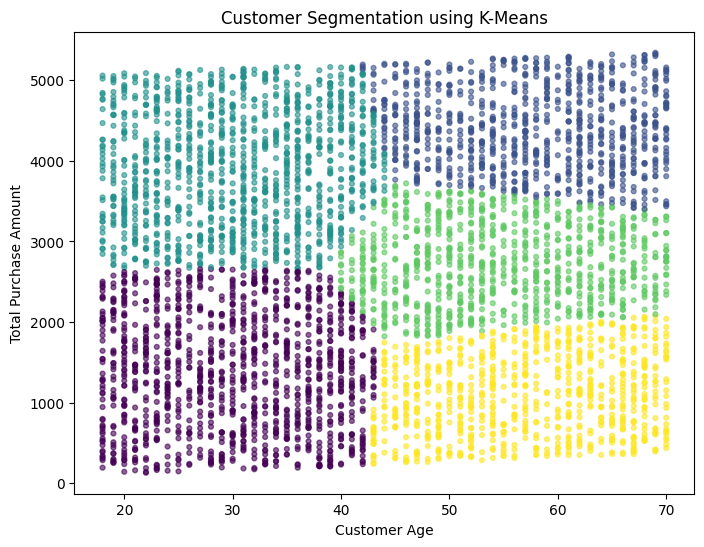

In [27]:
sample = df.sample(n=5000, random_state=42)

plt.figure(figsize=(8,6))

plt.scatter(
    sample["Customer Age"],
    sample["Total Purchase Amount"],
    c=sample["Cluster"],
    cmap="viridis",
    s=12,
    alpha=0.6
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Customer Age")
plt.ylabel("Total Purchase Amount")

plt.show()

In [28]:
df["Cluster"].value_counts()

,count
Cluster,
2.0,23612
0.0,23522
3.0,17544
1.0,17301
4.0,16505


In [29]:
df.to_csv("Customer_Behavior_Processed.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


# **Key Findings**
1. The dataset contains 250,000 customer transaction records with no significant missing values.

2. Electronics, Home, and Books are among the most frequently purchased product categories.

3. Customers use multiple payment methods, indicating diverse purchasing preferences.

4. Monthly sales fluctuate throughout the year, showing seasonal purchasing trends.

5. K-Means clustering grouped customers into five segments based on age and purchase amount, which can support targeted marketing strategies.

# **Recommendations**
1. Offer personalized promotions based on customer purchase history.

2. Strengthen loyalty programs for customers with higher purchase amounts.

3. Focus marketing campaigns on the most popular product categories.

4. Encourage digital payment options through exclusive offers.

5. Use customer segmentation to improve targeted advertising and customer retention.